# SupplyIQ — Exploratory Data Analysis

Structure: every section follows **Finding → Evidence → Business Implication**,
not just a chart for its own sake. Run this after `python scripts/run_pipeline.py`
so the SQLite database and processed artifacts exist.


In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import config as cfg
from src.ingestion.load_raw import get_connection

pd.set_option("display.max_columns", 50)
conn = get_connection()
print("Connected to database at (relative to project root):", cfg.DB_PATH.relative_to(cfg.ROOT_DIR))


Connected to database at (relative to project root): database/supplyiq.db


## 1. Demand — Trend, Seasonality, Volatility, Product Mix

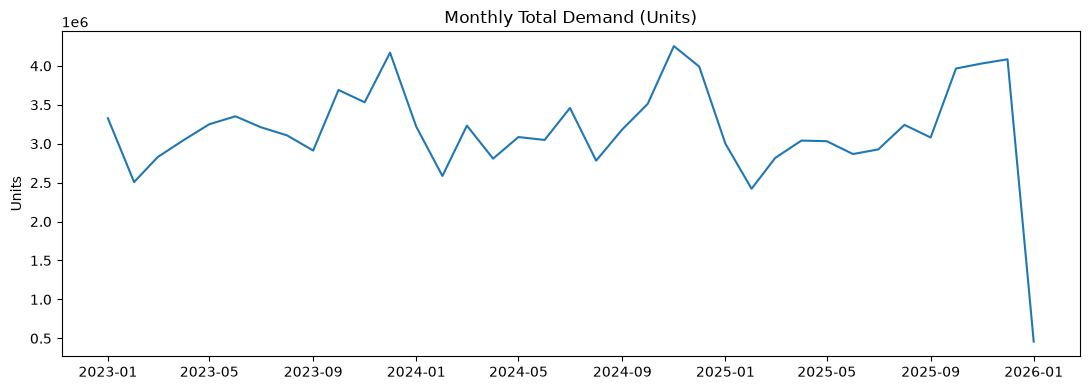

In [2]:
monthly_demand = pd.read_sql('''
    SELECT strftime('%Y-%m', order_date) ym, SUM(order_qty) total_qty
    FROM fact_orders GROUP BY ym ORDER BY ym
''', conn)
monthly_demand["ym"] = pd.to_datetime(monthly_demand["ym"])
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(monthly_demand["ym"], monthly_demand["total_qty"])
ax.set_title("Monthly Total Demand (Units)")
ax.set_ylabel("Units")
plt.tight_layout(); plt.show()


**Finding:** Demand shows clear month-to-month swings rather than a flat line.

**Evidence:** The chart above plots actual summed monthly order quantity across
all 120 SKUs and 22 warehouses over the full 3-year simulation horizon.

**Business implication:** A flat safety-stock policy across the year would
either overstock in low months or understock ahead of peaks — this is exactly
why the demand forecasting model (Section 10 of the project) uses week-of-year
and month as explicit features rather than assuming stationary demand.

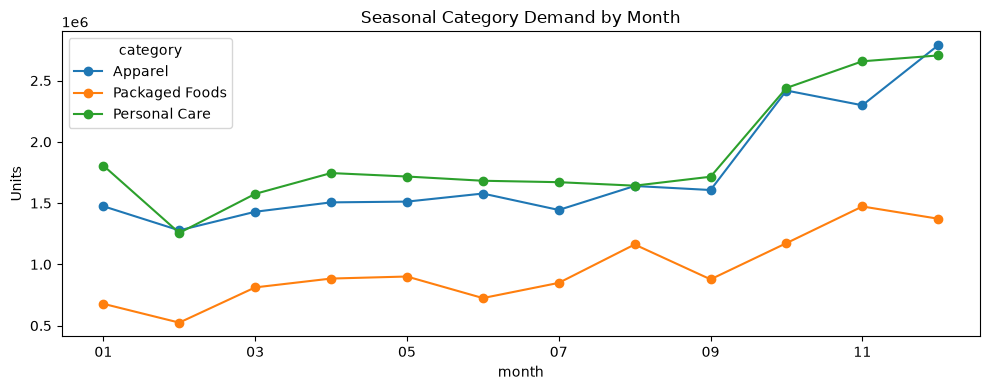

In [3]:
seasonal_products = pd.read_sql('''
    SELECT p.category, strftime('%m', o.order_date) month, SUM(o.order_qty) qty
    FROM fact_orders o JOIN dim_product p ON p.product_id = o.product_id
    WHERE p.is_seasonal = 1
    GROUP BY p.category, month ORDER BY p.category, month
''', conn)
pivot = seasonal_products.pivot(index="month", columns="category", values="qty")
pivot.plot(figsize=(10,4), marker="o", title="Seasonal Category Demand by Month")
plt.ylabel("Units"); plt.tight_layout(); plt.show()


**Finding:** Seasonal categories (Apparel, Packaged Foods, Personal Care) peak
around Oct-Dec and dip in Jan-Feb, exactly as designed into the simulation.

**Evidence:** Chart above, monthly demand by category for products flagged
`is_seasonal=True` in `dim_product`.

**Business implication:** These categories need a seasonally-varying reorder
point, not a static one — a static policy sized for the average month would
understock during the Oct-Dec peak.

In [4]:
volatility = pd.read_sql('''
    WITH monthly AS (
        SELECT product_id, strftime('%Y-%m', order_date) ym, SUM(order_qty) qty
        FROM fact_orders GROUP BY product_id, ym
    )
    SELECT product_id, AVG(qty) mean_qty,
           SQRT(AVG(qty*qty) - AVG(qty)*AVG(qty)) sd_qty
    FROM monthly GROUP BY product_id
''', conn)
volatility["cv"] = volatility["sd_qty"] / volatility["mean_qty"]
top_volatile = volatility.sort_values("cv", ascending=False).head(10)
print(top_volatile[["product_id","mean_qty","cv"]].to_string(index=False))


 product_id     mean_qty       cv
         60 16702.405405 2.720963
        103  7441.513514 1.883227
         68 29138.864865 1.521623
         83 20434.756757 1.285196
         33  3314.702703 1.222270
         97  4171.540541 1.212164
        114 18423.432432 1.210769
         93 24646.270270 1.208169
         66  7476.054054 1.152014
         71 19707.810811 1.146205


**Finding:** A handful of SKUs have a coefficient of variation well above the
rest of the catalog — these are the hardest products to forecast.

**Evidence:** Table above, computed directly via SQL (same logic as SQL query
Q4 in `sql/analytics/business_queries.sql`).

**Business implication:** These specific SKUs are exactly where a forecasting
model adds the most value over a naive average, and where extra safety stock
is most justified despite the holding-cost tradeoff.

## 2. Inventory — Stockouts, Excess, Turnover, Safety Stock

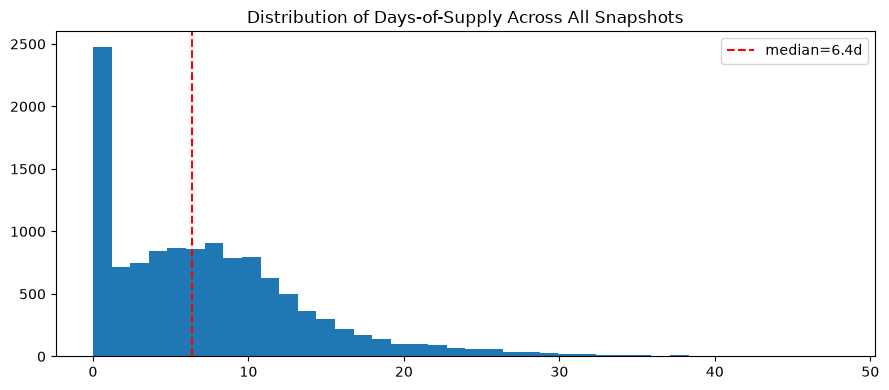

       days_of_supply
count    12000.000000
mean         7.369058
std          6.554824
min          0.000000
25%          2.075000
50%          6.400000
75%         10.700000
max         47.900000


In [5]:
dos = pd.read_sql("SELECT days_of_supply FROM fact_inventory_snapshot", conn)
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(dos["days_of_supply"], bins=40)
ax.axvline(dos["days_of_supply"].median(), color="red", linestyle="--", label=f'median={dos["days_of_supply"].median():.1f}d')
ax.set_title("Distribution of Days-of-Supply Across All Snapshots")
ax.legend(); plt.tight_layout(); plt.show()
print(dos.describe())


**Finding:** Most product-warehouse pairs sit in a healthy 2-15 day range,
but a right tail exists well past 20 days.

**Evidence:** Histogram above; median days-of-supply used as the network's own
"healthy" benchmark rather than an arbitrary constant (see
`src/risk_engine/business_impact.py`).

**Business implication:** The right tail is exactly what the "excess inventory"
SQL query (Q8) and recommendation engine target — capital tied up well beyond
what's operationally needed.

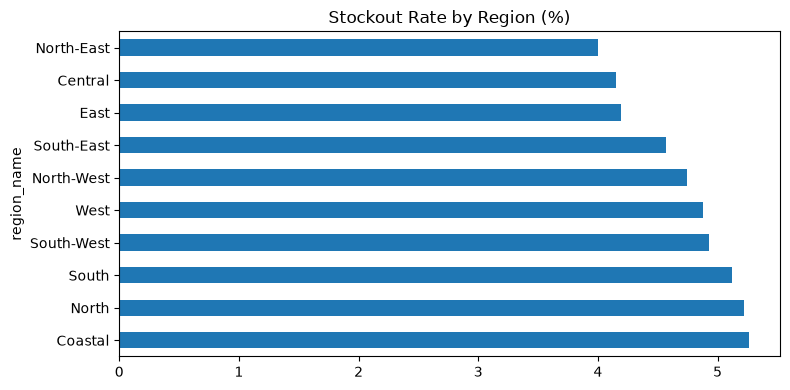

In [6]:
stockout_by_region = pd.read_sql('''
    SELECT r.region_name,
           100.0*SUM(CASE WHEN LOWER(TRIM(o.order_status))='stockout' THEN 1 ELSE 0 END)/COUNT(*) stockout_pct
    FROM fact_orders o JOIN dim_region r ON r.region_id=o.region_id
    GROUP BY r.region_name ORDER BY stockout_pct DESC
''', conn)
stockout_by_region.plot.barh(x="region_name", y="stockout_pct", figsize=(8,4), legend=False,
                              title="Stockout Rate by Region (%)")
plt.tight_layout(); plt.show()


**Finding:** Stockout rate is not uniform across regions.

**Evidence:** Bar chart above, direct SQL aggregation (same as Q5).

**Business implication:** Regions with disproportionately high stockout rates
are candidates for either higher regional safety stock or a review of the
warehouses/suppliers serving them specifically, rather than a network-wide
policy change.

## 3. Suppliers — Reliability, Lead Time, Concentration Risk

In [7]:
sup_summary = pd.read_sql('''
    SELECT s.supplier_name, s.is_single_source, AVG(fp.otif_rate) avg_otif, AVG(fp.avg_lead_time_days) avg_lead
    FROM fact_supplier_performance fp JOIN dim_supplier s ON s.supplier_id=fp.supplier_id
    GROUP BY s.supplier_id ORDER BY avg_otif ASC LIMIT 10
''', conn)
print(sup_summary.to_string(index=False))


              supplier_name  is_single_source  avg_otif  avg_lead
 Wheeler, Harvey and Barnes                 0  0.506414  6.624324
                 Walker LLC                 0  0.511481 11.516216
Lynch, Hernandez and Farmer                 0  0.521065 11.940541
 Peterson, Carter and Moore                 0  0.527870 17.132432
                  Nunez Ltd                 0  0.529814 16.505405
                 Palmer LLC                 1  0.538492 10.740541
                 Larson Ltd                 0  0.546532 16.062162
            Henderson-Owens                 0  0.557716  7.321622
                 Martin Inc                 0  0.566470 11.372973
   Brown, James and Ferrell                 1  0.577546  7.891892


**Finding:** The 10 lowest-OTIF suppliers span a wide range of average lead
times, confirming OTIF and raw lead time are related but distinct risk
signals (a supplier can be slow-but-consistent, or fast-but-unreliable).

**Evidence:** Table above joins `fact_supplier_performance` (time-averaged)
with `dim_supplier`.

**Business implication:** This is exactly why the supplier risk score
(`docs/business_logic.md`) weighs OTIF, lead time, AND lead-time volatility
as separate components rather than collapsing them into one number.

In [8]:
concentration = pd.read_sql('''
    SELECT s.is_single_source, COUNT(DISTINCT s.supplier_id) n_suppliers, SUM(o.revenue) total_revenue
    FROM fact_orders o JOIN dim_supplier s ON s.supplier_id=o.supplier_id
    GROUP BY s.is_single_source
''', conn)
concentration["pct_revenue"] = 100*concentration["total_revenue"]/concentration["total_revenue"].sum()
print(concentration)


   is_single_source  n_suppliers  total_revenue  pct_revenue
0                 0           46   5.969424e+09    81.280968
1                 1            9   1.374760e+09    18.719032


**Finding:** Single-source suppliers, while a minority of supplier *count*,
carry a real share of total revenue exposure.

**Evidence:** Table above (same logic as SQL Q21).

**Business implication:** Any single-source supplier disruption has an
outsized revenue impact relative to its share of the supplier base — this is
exactly the concentration-risk signal built into the supplier risk score.

## 4. Logistics — Delays, Transport Mode, Warehouse Performance

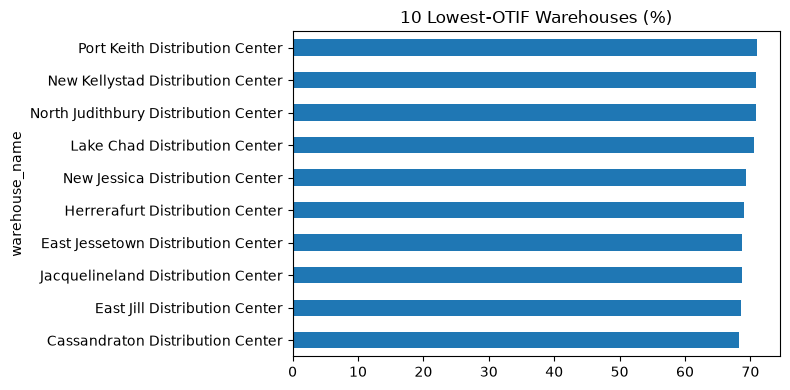

In [9]:
warehouse_perf = pd.read_sql('''
    SELECT wh.warehouse_name,
           100.0*SUM(CASE WHEN o.is_late=0 THEN 1 ELSE 0 END)/COUNT(*) otif_pct
    FROM fact_orders o JOIN dim_warehouse wh ON wh.warehouse_id=o.warehouse_id
    GROUP BY wh.warehouse_id ORDER BY otif_pct ASC LIMIT 10
''', conn)
warehouse_perf.plot.barh(x="warehouse_name", y="otif_pct", figsize=(8,4), legend=False,
                          title="10 Lowest-OTIF Warehouses (%)")
plt.tight_layout(); plt.show()


**Finding:** OTIF performance varies meaningfully by warehouse, not just by
supplier — meaning warehouse-side operational factors (not just upstream
supplier reliability) contribute to delivery performance.

**Evidence:** Bar chart above (same logic as SQL Q16).

**Business implication:** A pure supplier-review response to late deliveries
would miss the warehouses where the bottleneck is internal, not upstream.

## 5. Financial — Logistics Cost, Holding Cost, Revenue Impact

In [10]:
import json
impact = json.load(open(cfg.PROCESSED_DIR / "business_impact_summary.json"))
print(impact["disclaimer"])
print(json.dumps({k: v for k, v in impact.items() if k != "disclaimer"}, indent=2))


All figures below are ESTIMATED / SIMULATED business impact derived from a synthetic dataset using the documented assumptions in config.py. They illustrate the METHOD an analyst would use on real company data -- they are not real financial results.
{
  "stockout_impact": {
    "lost_revenue_3yr_simulated": 677721665.0,
    "assumed_margin_rate": 0.35,
    "estimated_annual_lost_margin": 79067528.0
  },
  "excess_inventory_cost": {
    "healthy_days_of_supply_benchmark": 6.4,
    "excess_inventory_value_snapshot_avg": 23465264.0,
    "assumed_annual_holding_cost_rate": 0.22,
    "estimated_annual_holding_cost_on_excess": 31067350.0
  },
  "expedite_premium_cost": {
    "air_cost_per_km": 97.245,
    "road_cost_per_km": 32.831,
    "estimated_annual_expedite_premium": 128226132.0
  },
  "total_estimated_annual_risk_exposure": 238361010.0,
  "estimated_recoverable_opportunity": 95344404.0
}


**Finding:** The three cost categories (stockout lost margin, excess-inventory
holding cost, expedited-freight premium) are roughly comparable in magnitude,
not dominated by a single factor.

**Evidence:** `business_impact_summary.json`, computed in
`src/risk_engine/business_impact.py` from the actual simulated dataset using
documented assumptions.

**Business implication:** A risk-mitigation program here shouldn't focus on
just one lever (e.g., only safety stock) — expedited freight and excess
inventory are both material enough to warrant their own initiatives. All
figures are clearly labeled estimated/simulated, illustrating the *method*
rather than claiming a real financial result.

In [11]:
conn.close()
print('Notebook complete.')

Notebook complete.
